# **Diabetes Model**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier




In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prince7489/diabetes-dataset")

print("Path to dataset files:", path)

# Importing files from directory and extracting the csv file

import os
path = os.path.join(path, os.listdir(path)[0])
print(path)

Using Colab cache for faster access to the 'diabetes-dataset' dataset.
Path to dataset files: /kaggle/input/diabetes-dataset
/kaggle/input/diabetes-dataset/diabetes_dataset.csv


In [ ]:
df = pd.read_csv(path)
df = df.drop('Patient_ID',axis=1)
df

,Age,Gender,BMI,Glucose_Level,Blood_Pressure,Insulin,Physical_Activity,Family_History,Diabetes_Outcome
0,58,F,36.4,151,102,98.5,86,Yes,1
1,71,M,28.3,185,80,294.3,29,No,0
2,48,M,27.1,172,82,186.5,108,Yes,1
3,34,F,24.0,86,139,181.0,46,No,0
4,62,M,19.2,83,106,228.2,86,Yes,0
...,...,...,...,...,...,...,...,...,...
495,69,M,18.7,156,148,249.8,11,Yes,1
496,44,F,33.3,139,121,287.2,118,No,1
497,43,M,24.5,115,69,249.0,30,No,0
498,32,M,38.3,177,80,15.4,77,Yes,1


In [ ]:
df.columns

Index(['Age', 'Gender', 'BMI', 'Glucose_Level', 'Blood_Pressure', 'Insulin',
       'Physical_Activity', 'Family_History', 'Diabetes_Outcome'],
      dtype='object')

229
271


<Axes: xlabel='Diabetes_Outcome', ylabel='count'>

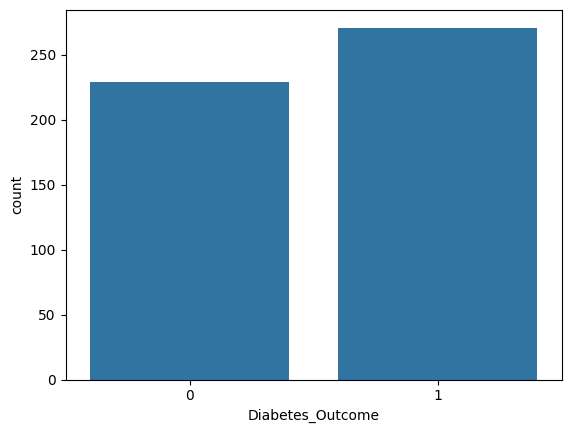

In [ ]:
print(df[df['Diabetes_Outcome'] == 0].shape[0])
print(df[df['Diabetes_Outcome'] == 1].shape[0])
sns.countplot(x='Diabetes_Outcome', data=df)

In [ ]:
df.isna().sum()

,0
Age,0
Gender,0
BMI,0
Glucose_Level,0
Blood_Pressure,0
Insulin,0
Physical_Activity,0
Family_History,0
Diabetes_Outcome,0


In [ ]:
df.replace({'Gender':{'M':0,'F':1}, 'Family_History':{'Yes':1, 'No':0}}, inplace=True)
df

/tmp/ipython-input-151617413.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Gender':{'M':0,'F':1}, 'Family_History':{'Yes':1, 'No':0}}, inplace=True)


,Age,Gender,BMI,Glucose_Level,Blood_Pressure,Insulin,Physical_Activity,Family_History,Diabetes_Outcome
0,58,1,36.4,151,102,98.5,86,1,1
1,71,0,28.3,185,80,294.3,29,0,0
2,48,0,27.1,172,82,186.5,108,1,1
3,34,1,24.0,86,139,181.0,46,0,0
4,62,0,19.2,83,106,228.2,86,1,0
...,...,...,...,...,...,...,...,...,...
495,69,0,18.7,156,148,249.8,11,1,1
496,44,1,33.3,139,121,287.2,118,0,1
497,43,0,24.5,115,69,249.0,30,0,0
498,32,0,38.3,177,80,15.4,77,1,1


In [ ]:
# Fisher score is a scoring method used to rank columns to determine which feature can seperate the classes efficiently
# Larger the fisher score, the good the feature is to seperate the classes

#Fisher score = (uA - uB)**2 / (varA + varB)

def fisher_score_binary_class(ds, index):
  A = ds[ds.iloc[:,-1] == 0].iloc[:,index]
  B = ds[ds.iloc[:,-1] == 1].iloc[:,index]
  uA = np.mean(A)
  uB = np.mean(B)
  varA = np.var(A, ddof=1)
  varB = np.var(B, ddof =1)
  fisher_score = (uA - uB)**2 / (varA + varB)
  return fisher_score

diab_fisher_score = []
for i in range(0, len(df.columns) - 1):
  diab_fisher_score.append((i, fisher_score_binary_class(df, i)))

diab_fisher_score.sort(key=lambda x: x[1], reverse=True)
for i,j in diab_fisher_score:
    print(df.columns[i] + " : " + str(j))

Glucose_Level : 0.6427164798591816
Family_History : 0.5365882698281232
BMI : 0.5216547518369732
Age : 0.004919555749223581
Physical_Activity : 0.0034598319169790903
Blood_Pressure : 0.0009679407952438851
Insulin : 0.00012797458842504268
Gender : 4.410352310549977e-05


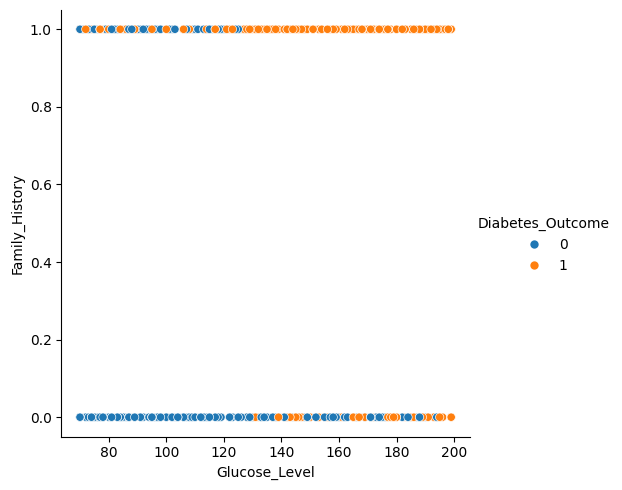

In [ ]:
sns.relplot(x='Glucose_Level', y='Family_History', hue='Diabetes_Outcome', data=df)

In [ ]:
print(len(df[df['Diabetes_Outcome'] == 1].index))
df.sort_values(by=['Glucose_Level', 'Family_History'], inplace=True)
df.reset_index(drop=True, inplace=True)
df.head(30)

idx = df[df['Diabetes_Outcome'] == 1][:42].index
df = df.drop(idx, axis=0)
df = df.reset_index(drop=True)
print(len(df[df['Diabetes_Outcome'] == 1].index))
df.tail(30)

271
229


,Age,Gender,BMI,Glucose_Level,Blood_Pressure,Insulin,Physical_Activity,Family_History,Diabetes_Outcome
428,33,0,21.7,192,150,72.7,23,1,1
429,63,1,38.3,192,156,213.3,59,1,1
430,42,1,18.4,192,79,127.9,10,1,1
431,39,0,32.4,192,151,273.6,29,1,1
432,79,0,39.4,192,95,196.4,33,1,1
433,70,0,37.9,193,122,254.6,38,0,1
434,78,1,36.5,193,64,71.5,67,0,1
435,34,0,26.2,193,92,152.1,43,1,1
436,53,0,18.2,193,156,41.7,39,1,1
437,21,0,22.5,194,159,264.8,17,0,0


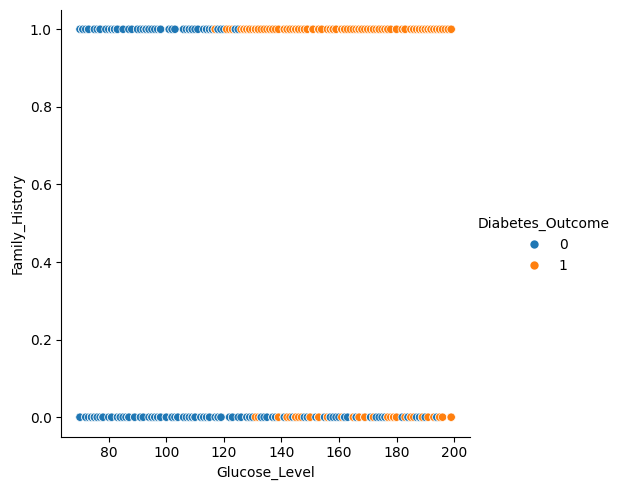

In [ ]:
sns.relplot(x='Glucose_Level', y='Family_History', hue='Diabetes_Outcome', data=df)

In [ ]:
Y = df['Diabetes_Outcome']
X = df.drop('Diabetes_Outcome', axis=1)

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=2)


In [ ]:
kernel = ['linear', 'rbf', 'poly', 'sigmoid']
for ker in kernel:
    classifier = svm.SVC(kernel=ker)
    classifier.fit(X_train, Y_train)

    X_train_pred = classifier.predict(X_train)
    X_test_pred = classifier.predict(X_test)

    print("Kernel: ", ker)
    print("Training Accuracy: ", accuracy_score(X_train_pred, Y_train))
    print("Testing Accuracy: ", accuracy_score(X_test_pred, Y_test))
    print('\n')

Kernel:  linear
Training Accuracy:  0.9234972677595629
Testing Accuracy:  0.9347826086956522


Kernel:  rbf
Training Accuracy:  0.8169398907103825
Testing Accuracy:  0.8260869565217391


Kernel:  poly
Training Accuracy:  0.8278688524590164
Testing Accuracy:  0.8478260869565217


Kernel:  sigmoid
Training Accuracy:  0.39344262295081966
Testing Accuracy:  0.32608695652173914




**Standardisation**

In [ ]:
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)


**Support Vector Machine**

In [ ]:
kernel = ['linear', 'rbf', 'poly', 'sigmoid']
for ker in kernel:
    classifier = svm.SVC(kernel=ker)
    classifier.fit(X_train_std, Y_train)

    X_train_pred_std = classifier.predict(X_train_std)
    X_test_pred_std = classifier.predict(X_test_std)

    print("Kernel: ", ker)
    print("Training Accuracy: ", accuracy_score(X_train_pred_std, Y_train))
    print("Testing Accuracy: ", accuracy_score(X_test_pred_std, Y_test))
    print('\n')

Kernel:  linear
Training Accuracy:  0.9234972677595629
Testing Accuracy:  0.9347826086956522


Kernel:  rbf
Training Accuracy:  0.9754098360655737
Testing Accuracy:  0.9891304347826086


Kernel:  poly
Training Accuracy:  0.9617486338797814
Testing Accuracy:  0.9130434782608695


Kernel:  sigmoid
Training Accuracy:  0.8797814207650273
Testing Accuracy:  0.9239130434782609




**Logistic Regression Model**

In [ ]:
logistic_regression_model = LogisticRegression()
logistic_regression_model.fit(X_train_std, Y_train)
logistic_regression_train_pred = logistic_regression_model.predict(X_train_std)
logistic_regression_test_pred = logistic_regression_model.predict(X_test_std)
print("Training Accuracy: ", accuracy_score(logistic_regression_train_pred, Y_train))
print("Testing Accuracy: ", accuracy_score(logistic_regression_test_pred, Y_test))
print('\n')


Training Accuracy:  0.9316939890710383
Testing Accuracy:  0.9347826086956522




**Random Forest Classifier**

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, Y_train)
rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)
print('Random Forest Classifier')
print("Training Accuracy: ", accuracy_score(rf_train_pred, Y_train))
print("Testing Accuracy: ", accuracy_score(rf_test_pred, Y_test))
print('\n')

Random Forest Classifier
Training Accuracy:  1.0
Testing Accuracy:  0.9782608695652174




In [ ]:
rf2 = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
rf2.fit(X_train, Y_train)
X_train_pred = rf2.predict(X_train)
X_test_pred = rf2.predict(X_test)
print("Training Accuracy: ", accuracy_score(X_train_pred, Y_train))
print("Testing Accuracy: ", accuracy_score(X_test_pred, Y_test))
print('\n')

Training Accuracy:  1.0
Testing Accuracy:  0.9891304347826086




**XGB Classifier**

In [ ]:
xgb = XGBClassifier()
xgb.fit(X_train,Y_train)
xgb_train_pred = xgb.predict(X_train)
xgb_test_pred = xgb.predict(X_test)
print('XGB Classifier')
print('Training Accuracy : ', accuracy_score(xgb_train_pred, Y_train))
print('Testing Accuracy : ', accuracy_score(xgb_test_pred, Y_test))

XGB Classifier
Training Accuracy :  1.0
Testing Accuracy :  0.9782608695652174


# **Diabetes Model Enhancement Using LDA**

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
LDA = LinearDiscriminantAnalysis(n_components=1)
X_train_std_lda = LDA.fit_transform(X_train_std,Y_train)
X_test_std_lda = LDA.transform(X_test_std)




In [ ]:
kernel = ['linear', 'rbf', 'poly', 'sigmoid']
for ker in kernel:
    classifier_lda = svm.SVC(kernel=ker)
    classifier_lda.fit(X_train_std_lda, Y_train)

    X_train_pred_std_lda = classifier_lda.predict(X_train_std_lda)
    X_test_pred_std_lda = classifier_lda.predict(X_test_std_lda)

    print("Kernel: ", ker)
    print("Training Accuracy: ", accuracy_score(X_train_pred_std_lda, Y_train))
    print("Testing Accuracy: ", accuracy_score(X_test_pred_std_lda, Y_test))
    print('\n')


logistic_regression_model_lda = LogisticRegression()
logistic_regression_model_lda.fit(X_train_std_lda, Y_train)
logistic_regression_train_pred_lda = logistic_regression_model_lda.predict(X_train_std_lda)
logistic_regression_test_pred_lda = logistic_regression_model_lda.predict(X_test_std_lda)
print("Training Accuracy: ", accuracy_score(logistic_regression_train_pred_lda, Y_train))
print("Testing Accuracy: ", accuracy_score(logistic_regression_test_pred_lda, Y_test))
print('\n')


Kernel:  linear
Training Accuracy:  0.9234972677595629
Testing Accuracy:  0.9239130434782609


Kernel:  rbf
Training Accuracy:  0.9234972677595629
Testing Accuracy:  0.9239130434782609


Kernel:  poly
Training Accuracy:  0.8961748633879781
Testing Accuracy:  0.9347826086956522


Kernel:  sigmoid
Training Accuracy:  0.9234972677595629
Testing Accuracy:  0.9130434782608695


Training Accuracy:  0.9234972677595629
Testing Accuracy:  0.9239130434782609


